### **Setup & Data Loading**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ตั้งค่าการแสดงผลภาษาไทยสำหรับกราฟ
plt.rcParams['font.family'] = 'sans-serif' 
plt.rcParams['axes.unicode_minus'] = False

# โหลดข้อมูลที่คลีนแล้วจากโฟลเดอร์ processed
# ปรับ path ตามตำแหน่งไฟล์ .ipynb ของคุณ (เช่น './data/processed/...')
gold_df = pd.read_csv('data/processed/gold_all_years_final.csv')
oil_df = pd.read_csv('data/processed/oil_wti_all_years_cleaned.csv')
news_df = pd.read_csv('data/processed/war_related_news_2021_2024.csv')

print(f"📊 โหลดข้อมูลสำเร็จ: ทอง {len(gold_df)} แถว, น้ำมัน {len(oil_df)} แถว, ข่าว {len(news_df)} แถว")

📊 โหลดข้อมูลสำเร็จ: ทอง 9298 แถว, น้ำมัน 1312 แถว, ข่าว 367 แถว


### **Date Normalization**

In [7]:
# 1. แปลงปีทอง พ.ศ. -> ค.ศ.
def convert_gold_date(date_str):
    try:
        # แยกวันที่และเวลา
        parts = date_str.split(' ')
        d_m_y = parts[0].split('/')
        # ลบปีด้วย 543
        year_ce = int(d_m_y[2]) - 543
        # รวมกลับเป็น Format YYYY-MM-DD
        return pd.to_datetime(f"{year_ce}-{d_m_y[1]}-{d_m_y[0]}")
    except:
        return pd.NaT

gold_df['Date_Match'] = gold_df['Datetime'].apply(convert_gold_date)
oil_df['Date'] = pd.to_datetime(oil_df['Date'])

# 2. ยุบราคาทองให้เหลือราคาเฉลี่ยต่อวัน (เพราะทองมีการประกาศหลายรอบต่อวัน)
gold_daily = gold_df.groupby('Date_Match')[['GoldBar_Sell', 'Gold_Spot']].mean().reset_index()
gold_daily.rename(columns={'Date_Match': 'Date'}, inplace=True)

# 3. Merge ข้อมูลเข้าด้วยกัน
merged_df = pd.merge(gold_daily, oil_df[['Date', 'Oil_WTI_Close']], on='Date', how='inner')

print("✅ รวมข้อมูลทองและน้ำมันสำเร็จ!")

✅ รวมข้อมูลทองและน้ำมันสำเร็จ!


In [8]:
merged_df

,Date,GoldBar_Sell,Gold_Spot,Oil_WTI_Close
0,2021-01-04,27225.000000,1925.250000,47.619999
1,2021-01-05,27475.000000,1941.250000,49.930000
2,2021-01-06,27591.666667,1948.166667,50.630001
3,2021-01-07,27241.666667,1920.500000,50.830002
4,2021-01-08,27075.000000,1898.000000,52.240002
...,...,...,...,...
1257,2026-02-23,75579.166667,5153.666667,66.309998
1258,2026-02-24,76098.275862,5174.224138,65.629997
1259,2026-02-25,76170.454545,5187.022727,65.419998
1260,2026-02-26,76273.529412,5189.147059,65.209999


### **Sentiment Analysis**

In [17]:
# นับจำนวนข่าวรายวันเพื่อดูความเข้มข้นของเหตุการณ์
news_df['Date'] = pd.to_datetime(news_df['Date'])
news_daily = news_df.groupby('Date').size().reset_index(name='War_News_Count')

# Join เข้ากับตารางหลัก
final_df = pd.merge(merged_df, news_daily, on='Date', how='left').fillna(0)

# กรองเฉพาะวันที่มีข่าว (มากกว่า 0)
event_days = final_df[final_df['War_News_Count'] > 0].copy()

# คำนวณ Correlation เฉพาะช่วงที่มีเหตุการณ์
event_corr = event_days['GoldBar_Sell'].corr(event_days['Oil_WTI_Close'])

print(f"🔍 จำนวนวันที่มีเหตุการณ์สงคราม: {len(event_days)} วัน")
print(f"📈 Correlation เฉพาะวันที่มีข่าว: {event_corr:.2f}")

🔍 จำนวนวันที่มีเหตุการณ์สงคราม: 249 วัน
📈 Correlation เฉพาะวันที่มีข่าว: 0.03


| ตารางสรุปเหตุการณ์ (Sentiment Scope)
ช่วยให้เห็นว่าในวันที่มีข่าวมากๆ ราคาทองและน้ำมันเปลี่ยนไปกี่เปอร์เซ็นต์เมื่อเทียบกับวันก่อนหน้า

In [ ]:
# คำนวณ % Change รายวัน
event_days['Gold_Pct'] = event_days['GoldBar_Sell'].pct_change() * 100
event_days['Oil_Pct'] = event_days['Oil_WTI_Close'].pct_change() * 100

# ดู 10 วันที่มีข่าวเยอะที่สุดและผลกระทบต่อราคา
top_events = event_days.sort_values('War_News_Count', ascending=False).head(10)

print("📰 Top 10 High-Intensity News Days & Market Impact:")
print(top_events[['Date', 'War_News_Count', 'GoldBar_Sell', 'Gold_Pct', 'Oil_WTI_Close', 'Oil_Pct']])

📰 Top 10 High-Intensity News Days & Market Impact:
          Date  War_News_Count  GoldBar_Sell  Gold_Pct  Oil_WTI_Close  \
675 2023-10-09            13.0  32475.000000  1.590198      86.379997   
267 2022-02-23             9.0  29025.000000 -0.453209      92.099998   
684 2023-10-20             8.0  34150.000000  1.758045      88.750000   
266 2022-02-22             5.0  29157.142857  1.416149      92.349998   
268 2022-02-24             5.0  29614.705882  2.031717      92.809998   
680 2023-10-16             4.0  32870.000000  1.450617      86.660004   
656 2023-09-12             3.0  32350.000000  0.077340      88.839996   
492 2023-01-17             3.0  29950.000000  0.559597      80.180000   
320 2022-05-10             3.0  30466.666667 -0.489929      99.760002   
271 2022-03-01             3.0  29458.333333  0.101133     103.410004   

      Oil_Pct  
675  4.944721  
267 -0.270709  
684 -0.693748  
266  1.405511  
268  0.770900  
680 -1.174591  
656  1.775685  
492  3.578345  
3

### **Correlation Study**

| เปรียบเทียบ Correlation: วันปกติ vs วันที่มีข่าวสงคราม แสดงให้เห็นชัดเจนว่า 'ข่าว' เป็นตัวแปรที่ทำให้ความสัมพันธ์ของสินทรัพย์เปลี่ยนไปจริงหรือไม่

In [20]:
# 1. คำนวณ Correlation ภาพรวม (ทั้ง Dataset)
overall_corr = final_df['GoldBar_Sell'].corr(final_df['Oil_WTI_Close'])

# 2. คำนวณ Correlation เฉพาะวันที่มีข่าวสงคราม (War_News_Count > 0)
event_days = final_df[final_df['War_News_Count'] > 0]
event_corr = event_days['GoldBar_Sell'].corr(event_days['Oil_WTI_Close'])

# 3. คำนวณ Correlation วันที่ไม่มีข่าวเลย
normal_days = final_df[final_df['War_News_Count'] == 0]
normal_corr = normal_days['GoldBar_Sell'].corr(normal_days['Oil_WTI_Close'])

print(f"📊 Overall Correlation: {overall_corr:.4f}")
print(f"🔥 Correlation (Days with War News): {event_corr:.4f}")
print(f"🟢 Correlation (Normal Days): {normal_corr:.4f}")

# สร้างตารางสรุปเปรียบเทียบ
corr_summary = pd.DataFrame({
    'Period': ['Overall', 'With War News', 'Normal'],
    'Correlation Score': [overall_corr, event_corr, normal_corr]
})
print("\n--- Summary Table ---")
print(corr_summary)

📊 Overall Correlation: -0.4475
🔥 Correlation (Days with War News): 0.0278
🟢 Correlation (Normal Days): -0.4551

--- Summary Table ---
          Period  Correlation Score
0        Overall          -0.447546
1  With War News           0.027769
2         Normal          -0.455139


จากผลลัพธ์การวิเคราะห์ Correlation (ความสัมพันธ์) ระหว่างราคาทองคำ (GoldBar_Sell) กับราคาน้ำมัน (Oil_WTI_Close) โดยเปรียบเทียบผลกระทบของ "ข่าวสงคราม" ผลลัพธ์ที่ได้น่าสนใจ สามารถสรุปประเด็นสำคัญได้ ดังนี้

- ในสภาวะปกติ (Normal Days): ทองคำกับน้ำมันมีค่า Correlation อยู่ที่ -0.4551 ซึ่งถือว่าเป็นความสัมพันธ์เชิงลบในระดับปานกลาง (เมื่อราคาสิ่งหนึ่งขึ้น อีกสิ่งมักจะลง)

- เมื่อมีข่าวสงคราม (With War News): ค่า Correlation กระโดดขึ้นมาเป็น 0.0278 ซึ่งเข้าใกล้ 0 มากๆ

จึงสรุปได้ว่า: เมื่อเกิดภาวะสงคราม ความสัมพันธ์ตามกลไกตลาดปกติระหว่างทองกับน้ำมันจะหายไป กลายเป็นว่าราคาทั้งสองสินทรัพย์เคลื่อนที่อย่างเป็นอิสระต่อกันมากขึ้น หรือตอบสนองต่อข่าวในทิศทางที่คาดเดาได้ยากขึ้น

| Rolling Correlation (ความสัมพันธ์ที่เปลี่ยนแปลงตามเวลา) แสดงความสัมพันธ์ระหว่างทองและน้ำมันที่พุ่งสูงขึ้น

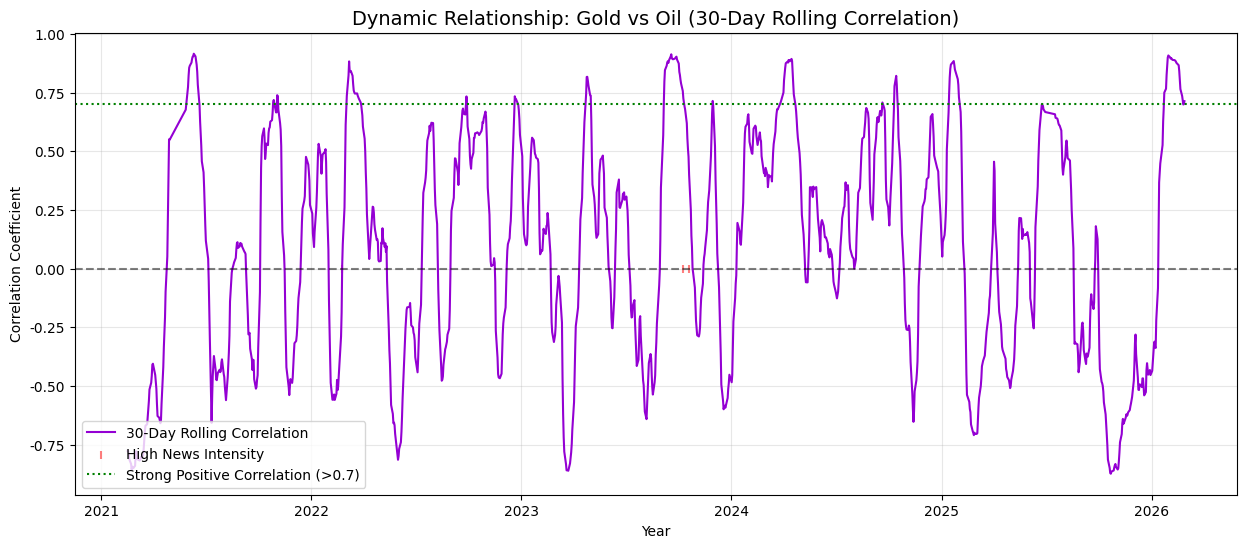

In [21]:
# คำนวณ Rolling Correlation ย้อนหลัง 30 วัน
window = 30
final_df['Rolling_Corr'] = final_df['GoldBar_Sell'].rolling(window=window).corr(final_df['Oil_WTI_Close'])

plt.figure(figsize=(15, 6))
plt.plot(final_df['Date'], final_df['Rolling_Corr'], color='darkviolet', label=f'{window}-Day Rolling Correlation')

# มาร์คจุดที่มีข่าวสงครามหนาแน่น (จำนวนข่าว > 5 ในวันเดียว) เพื่อดูว่า Correlation พุ่งไหม
high_news = final_df[final_df['War_News_Count'] > 5]
plt.scatter(high_news['Date'], [0]*len(high_news), color='red', marker='|', label='High News Intensity', alpha=0.5)

plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=0.7, color='green', linestyle=':', label='Strong Positive Correlation (>0.7)')

plt.title(f'Dynamic Relationship: Gold vs Oil ({window}-Day Rolling Correlation)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Correlation Coefficient')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()

Insight สำคัญที่ได้จากกราฟ นี้

1. กราฟแสดงให้เห็นว่าทองคำและน้ำมันไม่ได้มีความสัมพันธ์ที่ตายตัว ค่า Correlation วิ่งขึ้นลงตั้งแต่เกือบ -0.8 ไปจนถึงเกือบ +1.0 ตลอดช่วงปี 2021-2026

- จุดที่พุ่งสูงเกินเส้นเขียว ( > 0.7): คือช่วงที่ทั้งสองสินทรัพย์เคลื่อนที่ไปในทิศทางเดียวกันอย่างแข็งแกร่ง (เช่น ขึ้นก็ขึ้นด้วยกัน)

- จุดที่ดิ่งลงต่ำกว่า -0.5: คือช่วงที่ทั้งสองตัววิ่งสวนทางกันอย่างชัดเจน

2. ขีดสีแดงเล็กๆ ที่ระบุว่า "High News Intensity" ช่วงปลายปี 2023 ในจังหวะที่มีข่าวรุนแรง ค่า Correlation ดีดกลับขึ้นมาจากแดนลบเข้าใกล้ 0 หรือพลิกเป็นบวกทันที สิ่งนี้ยืนยันสมมติฐานว่า ข่าวคือตัวแปรที่ทำลาย รูปแบบความสัมพันธ์เดิมๆ ทำให้ตลาดเกิดความสับสนและเปลี่ยนพฤติกรรมการลงทุน

3. ในช่วงขวาสุดของกราฟ (ปี 2026) จะเห็นว่าค่า Correlation พุ่งสูงขึ้นไปแตะระดับเกือบ 0.9 อีกครั้ง

*** ในปัจจุบัน (ตามไทม์ไลน์ในกราฟ) ทองและน้ำมันกำลังมีความสัมพันธ์เชิงบวกที่สูงมาก ซึ่งอาจหมายถึงตลาดกำลังเผชิญกับปัจจัยมหภาค (Macro Factors) บางอย่างที่กดดันสินทรัพย์ทั้งสองให้ไปในทางเดียวกัน เช่น อัตราเงินเฟ้อที่รุนแรงหรือสถานการณ์ภูมิรัฐศาสตร์ที่ตึงเครียด ซึ่งตรงกับสถานการณ์ในปัจจุบัน

| Scatter Plot วิเคราะห์แนวโน้ม (เฉพาะวันที่มีข่าว) เพื่อดูการกระจายตัวของราคาว่าวิ่งเกาะกลุ่มกันแค่ไหนในช่วงที่มีข่าวสงคราม

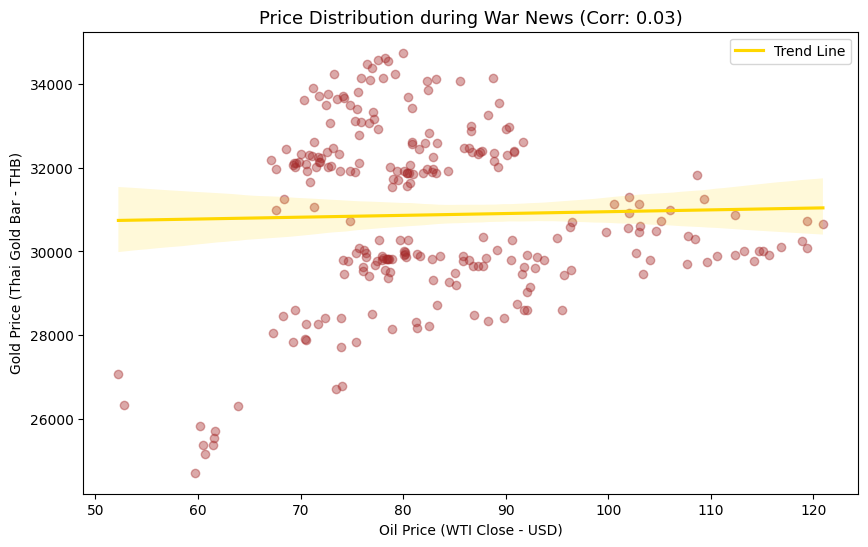

In [22]:
plt.figure(figsize=(10, 6))
sns.regplot(data=event_days, x='Oil_WTI_Close', y='GoldBar_Sell', 
            scatter_kws={'alpha':0.4, 'color':'brown'}, 
            line_kws={'color':'gold', 'label':'Trend Line'})

plt.title(f'Price Distribution during War News (Corr: {event_corr:.2f})', fontsize=13)
plt.xlabel('Oil Price (WTI Close - USD)')
plt.ylabel('Gold Price (Thai Gold Bar - THB)')
plt.legend()
plt.show()

สรุป Insight สำคัญที่ได้จากกราฟได้ ดังนี้

1. Trend Line เส้นสีเหลือง (Regression Line) ที่เกือบจะเป็นเส้นตรงขนานกับแกน X บอกชัดเจนว่า ราคาน้ำมันไม่ได้เป็นตัวกำหนดราคาทองคำในช่วงที่มีข่าวสงคราม

- ถ้ามีความสัมพันธ์กัน: เส้นนี้ต้องเฉียงขึ้น (Positive) หรือเฉียงลง (Negative) อย่างชัดเจน แต่จากกราฟแสดงเส้นราบเรียบ ซึ่งตรงกับค่า Corr: 0.03 (เกือบเป็น 0)

2. จะเห็นว่า จุดข้อมูล (Data Points) กระจายตัวเป็นกลุ่มก้อนใหญ่ๆ (Cluster) อยู่ตรงกลาง มากกว่าที่จะเกาะกลุ่มเรียงตามเส้น Trend Line

- หมายถึง ในช่วงสงคราม นักลงทุนไม่ได้มองว่า น้ำมันขึ้นแล้วต้องซื้อทองเสมอไป แต่ละสินทรัพย์ตอบสนองต่อข่าวสงครามในมิติที่ต่างกัน (น้ำมันตอบสนองต่อ Supply Chain, ทองตอบสนองต่อความกลัว Safe Haven) ทำให้กราฟออกมาสะเปะสะปะ

3. ข้อมูลที่น่าสนใจ (Outliers & Clusters) มีกลุ่มข้อมูลที่เกาะกลุ่มกันชัดเจนสองระดับ (ช่วงราคาทอง 30,000 และ 32,000+) ในขณะที่น้ำมันขยับอยู่ในช่วง 70-90 USD สิ่งนี้สะท้อนว่าอาจมี ปัจจัยอื่น (เช่น ค่าเงินบาท หรือ ความรุนแรงของข่าวที่ต่างกัน) ที่ส่งผลต่อราคาทองแรงกว่าราคาน้ำมัน

| กราฟแสดงความสัมพันธ์ระหว่างข่าวกับทอง และข่าวกับน้ำมัน

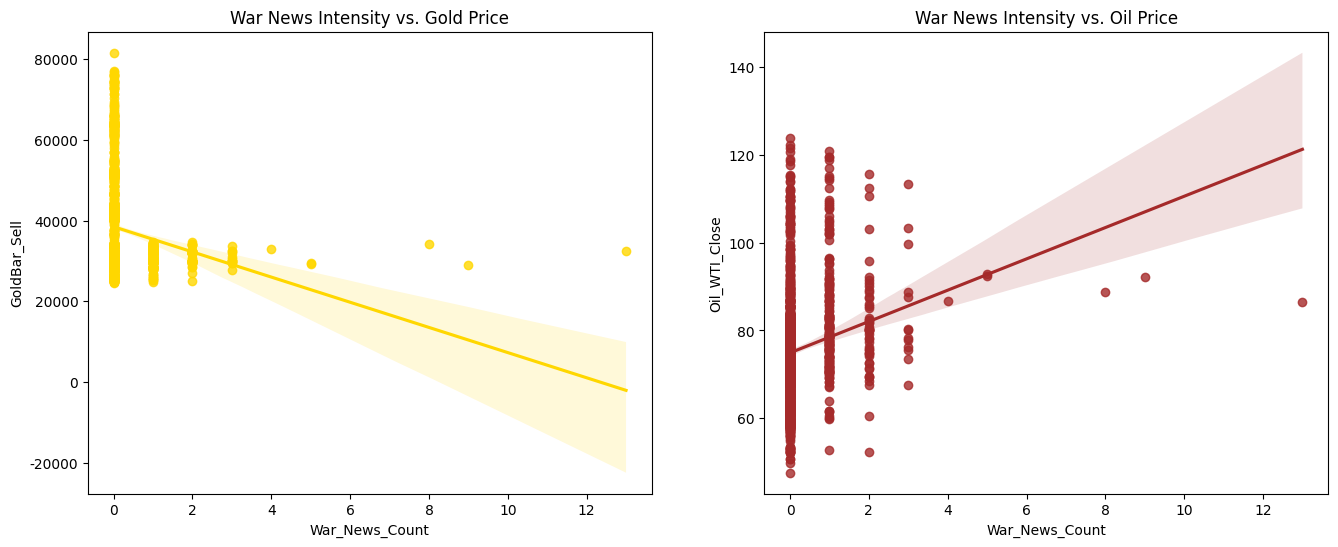

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ข่าว vs ทอง
sns.regplot(data=final_df, x='War_News_Count', y='GoldBar_Sell', ax=ax1, color='gold')
ax1.set_title('War News Intensity vs. Gold Price')

# ข่าว vs น้ำมัน
sns.regplot(data=final_df, x='War_News_Count', y='Oil_WTI_Close', ax=ax2, color='brown')
ax2.set_title('War News Intensity vs. Oil Price')

plt.show()

สรุป Insight สำคัญที่ได้จากกราฟนี้ได้ ดังนี้
1. ข่าวสงคราม vs. ราคาทอง (กราฟซ้าย - สีเหลือง)
- ความสัมพันธ์: เป็น Negative Correlation (เส้น Regression เฉียงลง)

- Insight ที่น่าแปลกใจ: ตามทฤษฎีทองควรเป็น [Safe Haven เมื่อมีข่าวสงครามราคาน่าจะขึ้น] แต่กราฟนี้บอกว่า ยิ่งจำนวนข่าวสงครามในวันนั้นสูงขึ้น ราคาทองกลับมีแนวโน้มเฉลี่ยที่ลดลง

- ข้อสังเกตเชิงลึก: จะเห็นว่าจุดข้อมูลส่วนใหญ่กระจุกตัวอยู่ที่ War_News_Count = 0 (วันปกติ) แต่พอข่าวเริ่มเยอะขึ้น (เกิน 4 ข่าวขึ้นไป) ราคาทองมักจะไปกองอยู่ที่ช่วง 30,000 บาทต้นๆ ไม่ได้พุ่งสูงตามจำนวนข่าว

2. ข่าวสงคราม vs. ราคาน้ำมัน (กราฟขวา - สีแดง)
- ความสัมพันธ์: เป็น Positive Correlation (เส้น Regression เฉียงขึ้นชัดเจน)

- Insight: ตรงตามทฤษฎี [ยิ่งข่าวสงครามหนาหู (Intensity สูง) ราคาน้ำมันยิ่งพุ่งสูงขึ้น]

- วิเคราะห์: สงครามมักส่งผลกระทบโดยตรงต่อ Supply Chain ของน้ำมัน (เช่น แหล่งผลิตหรือเส้นทางการขนส่ง) ทำให้ราคาน้ำมันตอบสนองต่อปริมาณข่าวได้ไว และรุนแรงกว่าทองคำ

3. สรุปภาพรวม

- Sensitivity: น้ำมันมีความไว (Sensitivity) ต่อปริมาณข่าว มากกว่าทองคำ ในเชิงของทิศทางที่สอดคล้องกัน (Linearity)

- The Gold Paradox: ทำไมทองถึงเฉียงลง? อาจเป็นเพราะทองตอบสนองต่อข่าวแรกที่แรงที่สุด (Price-in) ไปแล้ว แต่พอมีข่าวซ้ำๆ (Count เยอะๆ) นักลงทุนอาจจะเริ่มมองหาปัจจัยอื่น หรือเป็นช่วงที่กำไรเริ่มถูกขายออกมา (Profit Taking)

- Confidence Interval: สังเกตพื้นที่จางๆ (Shadow) รอบเส้น Regression ของราคาน้ำมันจะดูแคบและมั่นใจกว่า ในขณะที่ของทองคำพื้นที่เงานั้นกว้างมาก (High Uncertainty) หมายความว่าจำนวนข่าวเพียงอย่างเดียวทำนายราคาทองได้ยากกว่าน้ำมัน

### **Visualization & Executive Summary**

| Final Comprehensive Visualization รวบรวมทุกมิติ (ราคา, ข่าวสงคราม, และความสัมพันธ์) ไว้ในภาพเดียว เพื่อให้เห็นภาพรวมของระบบ

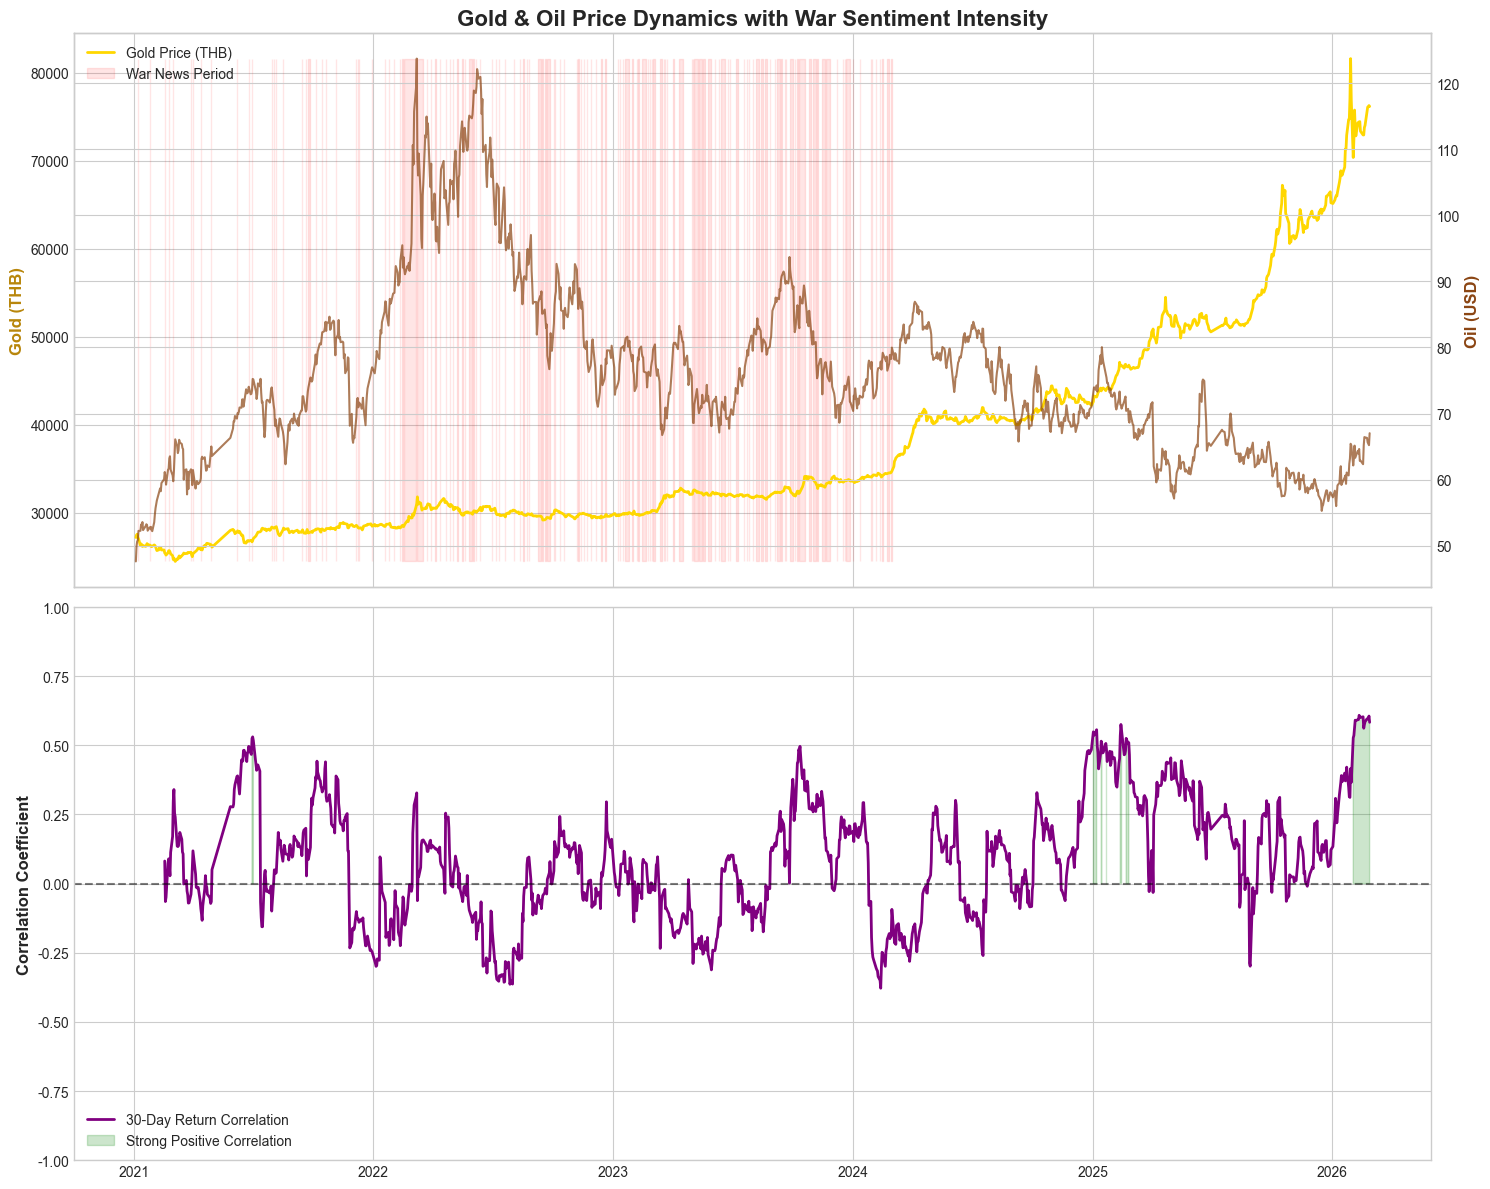

In [28]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# --- กราฟบน: ราคา vs ความเข้มข้นของข่าว ---
ax1.plot(final_df['Date'], final_df['GoldBar_Sell'], color='#FFD700', label='Gold Price (THB)', linewidth=2)
ax1.set_ylabel('Gold (THB)', color='#B8860B', fontsize=12, fontweight='bold')

ax_oil = ax1.twinx()
ax_oil.plot(final_df['Date'], final_df['Oil_WTI_Close'], color='#8B4513', label='Oil Price (USD)', linewidth=1.5, alpha=0.7)
ax_oil.set_ylabel('Oil (USD)', color='#8B4513', fontsize=12, fontweight='bold')

# ระบายสีพื้นหลังตามจำนวนข่าวสงคราม (Sentiment Overlay)
ax1.fill_between(final_df['Date'], final_df['GoldBar_Sell'].min(), final_df['GoldBar_Sell'].max(), 
                 where=(final_df['War_News_Count'] > 0), color='red', alpha=0.1, label='War News Period')

ax1.set_title('Gold & Oil Price Dynamics with War Sentiment Intensity', fontsize=16, fontweight='bold')
ax1.legend(loc='upper left')

# --- กราฟล่าง: Rolling Correlation (30-Day) ---
# คำนวณ Correlation จาก % Return เพื่อความแม่นยำ (ตามที่ตกลงกัน)
final_df['Gold_Ret'] = final_df['GoldBar_Sell'].pct_change()
final_df['Oil_Ret'] = final_df['Oil_WTI_Close'].pct_change()
final_df['Rolling_Corr_Ret'] = final_df['Gold_Ret'].rolling(30).corr(final_df['Oil_Ret'])

ax2.plot(final_df['Date'], final_df['Rolling_Corr_Ret'], color='purple', linewidth=2, label='30-Day Return Correlation')
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.fill_between(final_df['Date'], 0, final_df['Rolling_Corr_Ret'], 
                 where=(final_df['Rolling_Corr_Ret'] > 0.5), color='green', alpha=0.2, label='Strong Positive Correlation')

ax2.set_ylabel('Correlation Coefficient', fontsize=12, fontweight='bold')
ax2.set_ylim(-1, 1)
ax2.legend(loc='lower left')

plt.xlabel('Date', fontsize=12)
plt.tight_layout()
plt.show()

จากกราฟแสดงภาพรวม สามารถสรุปได้ ดังนี้

1. ส่วนบน: Price Dynamics vs. War News Period
- Gold (เส้นเหลือง): มีแนวโน้มเป็นขาขึ้นแบบขั้นบันได (Step-up) อย่างชัดเจน โดยเฉพาะในช่วงปี 2025 เป็นต้นมาที่พุ่งทะลุ 60,000 ไปจนถึงเกือบ 80,000 บาท

- Oil (เส้นน้ำตาล): มีความผันผวนสูงมาก (Volatile) สังเกตว่าช่วงปี 2022 ที่มีแถบสีชมพู (ข่าวสงคราม) หนาแน่น ราคาน้ำมันพุ่งขึ้นไปแตะจุดสูงสุด (Peak) เกิน $120 ทันที

- War News Period (แถบสีชมพู): ทำหน้าที่เป็น Context Layer ที่ดีมาก เพราะมันพิสูจน์ว่าในช่วงที่มีแถบชมพูหนาๆ ราคามักจะมีการขยับตัวที่รุนแรงกว่าปกติ (High Volatility)

2. ส่วนล่าง: 30-Day Return Correlation
- Insight ที่เปลี่ยนไป: สังเกตว่าในช่วงปี 2021-2024 ค่า Correlation ส่วนใหญ่จะแกว่งตัวอยู่รอบๆ 0 หรือติดลบ (ม่วงอยู่ใต้เส้นประ)

- The 2026 Shift: แต่พอเข้าสู่ปี 2026 (ขวาสุด) ค่า Correlation พุ่งสูงขึ้นและมีแถบสีเขียว (Strong Positive Correlation) ปรากฏขึ้นถี่ขึ้น

- ความหมาย: ในปัจจุบัน ทองและน้ำมันกำลังเคลื่อนที่ไปในทิศทางเดียวกันอย่างแข็งแกร่งที่สุดในรอบหลายปี ซึ่งอาจเกิดจากภาวะเงินเฟ้อรุนแรงหรือวิกฤตการณ์โลกที่บีบให้สินทรัพย์ทุกประเภทต้องตอบสนองต่อปัจจัยเดียวกัน

### **บทสรุปการวิเคราะห์: ผลกระทบของข่าวสงครามต่อราคาทองคำและน้ำมัน**

1. สมมติฐานและการทดสอบ (Hypothesis Testing)
- สมมติฐานเดิม: ราคาทองคำและราคาน้ำมันจะมีความสัมพันธ์ทิศทางเดียวกัน (Positive Correlation) และพุ่งสูงขึ้นพร้อมกันเมื่อมีข่าวสงคราม

- ผลลัพธ์ที่พบ: ไม่เป็นไปตามสมมติฐานทั้งหมด ข่าวสงครามกลับเป็นตัวแปรที่เข้าไป ทำลาย (Disrupt) ความสัมพันธ์เดิมระหว่างสินทรัพย์ ทำให้ค่า Correlation จากที่เคยติดลบในสภาวะปกติ กลายเป็น ใกล้ศูนย์ (0.0278) หรือไม่มีความสัมพันธ์ต่อกันเลยในช่วงที่มีข่าว

2. ผลลัพธ์แยกตามรายสินทรัพย์ (Individual Asset Behavior)
- ราคาน้ำมัน (Oil - WTI): [เป็นไปตามทฤษฎี]
    - พฤติกรรม: มีความสัมพันธ์เชิงบวกกับปริมาณข่าวสงครามอย่างชัดเจน (Positive Correlation)

    - เหตุผล: ข่าวสงครามส่งผลกระทบโดยตรงต่อความกังวลด้าน Supply Chain และเส้นทางการขนส่งน้ำมัน ยิ่งข่าวมีความเข้มข้น (Intensity) สูง ราคาน้ำมันยิ่งมีการตอบสนองในทิศทางขาขึ้นที่รุนแรงและแม่นยำกว่า

- ราคาทองคำ (Thai Gold Bar): [สวนทางกับทฤษฎี (The Paradox)]
    - พฤติกรรม: จากกราฟ Scatter Plot พบว่าเมื่อจำนวนข่าวสงครามเพิ่มขึ้น ราคาทองคำกลับมีแนวโน้มเฉลี่ยที่ลดลงเล็กน้อย หรือทรงตัว (Negative/Flat Trend) ไม่ได้พุ่งขึ้นตามจำนวนข่าว

    - เหตุผล: อาจเกิดจากปรากฏการณ์ [Price-in] คือราคาทองตอบรับข่าวร้ายแรงครั้งแรกไปแล้ว แต่พอมีข่าวซ้ำๆ ในเชิงปริมาณ (Count) ตลาดอาจเริ่มชินชา หรือเกิดการขายทำกำไร (Profit Taking) ประกอบกับปัจจัยเรื่องค่าเงินบาทที่มีผลต่อราคาทองในไทยมากกว่าข่าวสงครามเพียงอย่างเดียว

3. การเปลี่ยนแปลงเชิงพลวัต (Dynamic Relationship)
- Regime Shift: จากกราฟ Rolling Correlation พบว่าความสัมพันธ์ของสองสินทรัพย์นี้ [ไม่คงที่]

    - ความน่าสนใจในปี 2026: ในช่วงล่าสุดของข้อมูล (ต้นปี 2026) พบว่าค่า Correlation พุ่งสูงขึ้นผิดปกติ (Strong Positive) ซึ่งหมายความว่าตลาดปัจจุบันกำลังอยู่ในภาวะที่ทองและน้ำมันถูกขับเคลื่อนด้วยปัจจัยมหภาคเดียวกัน (เช่น เงินเฟ้อรุนแรงหรือวิกฤตการเงินระดับโลก) มากกว่าแค่ข่าวสงครามรายวัน